# Histogram Equalization

## The Problem of Contrast

A grayscale image $f : \Omega \to [0,1]$ can have poor contrast when its pixel values are concentrated in a narrow range of intensities. **Histogram equalization** is a global point-wise transform that remaps pixel values to achieve a more uniform (ideally flat) histogram.

## Mathematical Framework

Let $F : [0,1] \to [0,1]$ denote the **empirical CDF** of the pixel values:
$$F(t) = \frac{1}{|\Omega|} \#\{x \in \Omega : f(x) \leq t\}$$

The **histogram equalization** transform is:
$$\hat{f}(x) = F(f(x))$$

If $f$ has a density $p_f$, then $\hat{f} = F \circ f$ has density $p_{\hat{f}}(t) = p_f(F^{-1}(t)) / F'(F^{-1}(t)) = 1$, i.e., a uniform distribution — this is the **probability integral transform**.

## Histogram Specification (Transfer)

More generally, one can match a **target histogram** with CDF $G$. The transfer function becomes:
$$\hat{f}(x) = G^{-1}(F(f(x)))$$

This is the **optimal transport map** from the empirical distribution of $f$ to the target distribution $G$ on the real line — a 1D Wasserstein-2 problem with closed-form solution.

### Environment setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider

### Synthetic test image

We create a grayscale test image with a concentrated (dark) histogram by combining a structured pattern with a nonlinear intensity warp. The image mimics a natural photograph with poor exposure.

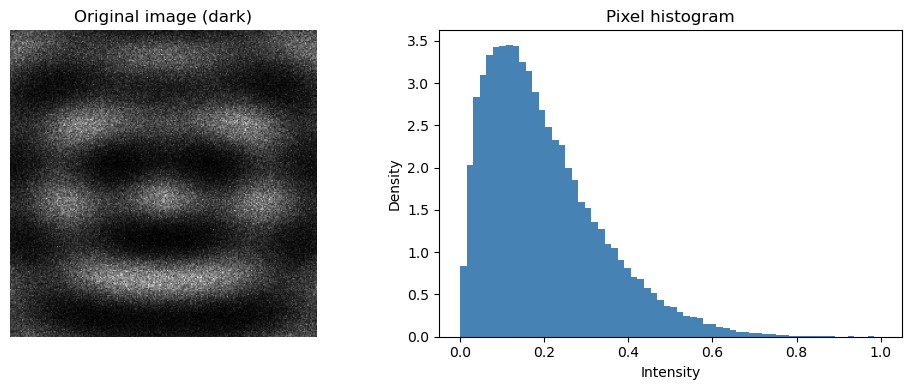

In [2]:
rng = np.random.default_rng(42)
n = 256
x = np.linspace(0, 1, n)
Y, X = np.meshgrid(x, x)

# Structured image: Gabor-like pattern with smooth envelope
R = np.sqrt((X - 0.5)**2 + (Y - 0.5)**2)
f_raw = (
    0.5 * np.sin(8 * np.pi * X) * np.exp(-4 * (Y - 0.5)**2)
    + 0.3 * np.cos(6 * np.pi * R)
    + 0.2 * rng.standard_normal((n, n))
)
# Normalize to [0,1]
f_raw = (f_raw - f_raw.min()) / (f_raw.max() - f_raw.min())
# Apply a power warp to concentrate histogram in low intensities
f = f_raw ** 2.5

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(f, cmap='gray', vmin=0, vmax=1)
axes[0].set_title('Original image (dark)')
axes[0].axis('off')
axes[1].hist(f.ravel(), bins=64, color='steelblue', density=True)
axes[1].set_title('Pixel histogram')
axes[1].set_xlabel('Intensity'); axes[1].set_ylabel('Density')
plt.tight_layout(); plt.savefig('original.png', dpi=100, bbox_inches='tight'); plt.show()

### Histogram equalization via empirical CDF

Sorting the pixel values gives access to the empirical CDF $F$ at no extra cost. We assign to each pixel its **rank** in the sorted order, rescaled to $[0,1]$:
$$\hat{f}(x_i) = \frac{\text{rank}(f(x_i))}{N-1}, \quad N = |\Omega|$$

This is exactly $F(f(x_i))$ computed via the order statistics.

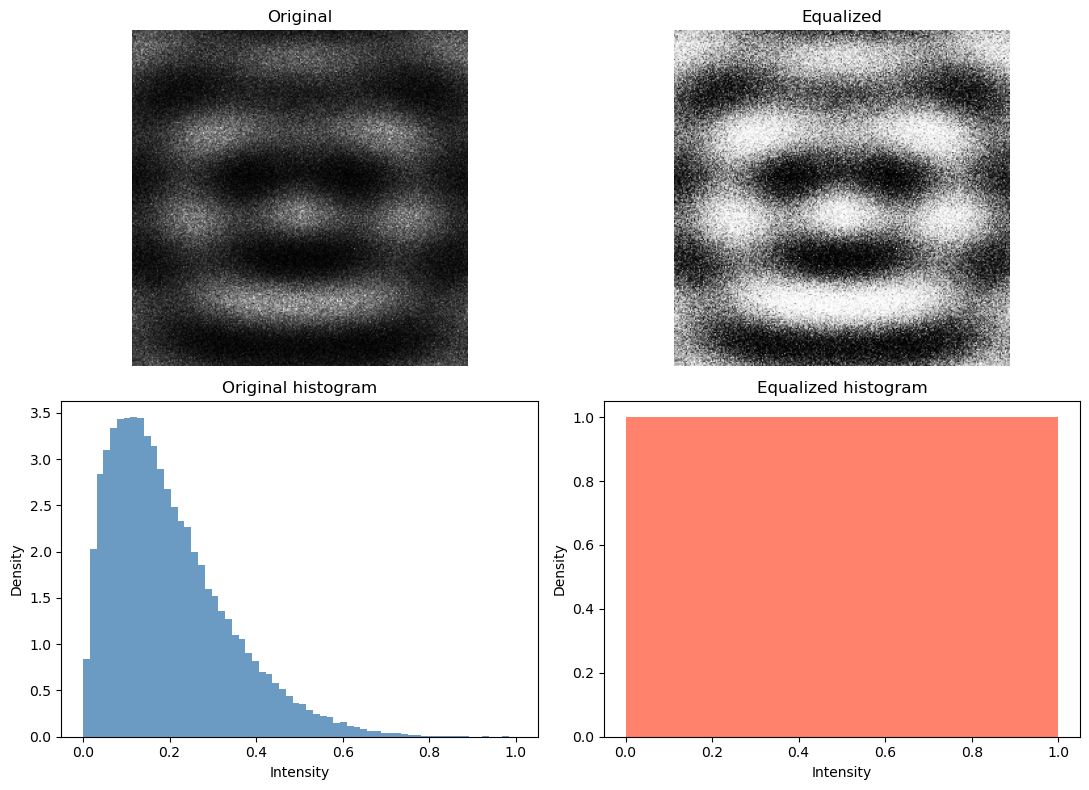

In [3]:
def hist_equalize(img):
    """Histogram equalization via rank transform."""
    flat = img.ravel()
    N = len(flat)
    idx = np.argsort(flat)         # sorted pixel indices
    eq = np.empty(N)
    eq[idx] = np.linspace(0, 1, N)  # assign rank / (N-1)
    return eq.reshape(img.shape)

f_eq = hist_equalize(f)

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
axes[0,0].imshow(f, cmap='gray', vmin=0, vmax=1)
axes[0,0].set_title('Original'); axes[0,0].axis('off')
axes[0,1].imshow(f_eq, cmap='gray', vmin=0, vmax=1)
axes[0,1].set_title('Equalized'); axes[0,1].axis('off')

for ax, img, label, c in zip(axes[1], [f, f_eq], ['Original', 'Equalized'], ['steelblue','tomato']):
    ax.hist(img.ravel(), bins=64, color=c, density=True, alpha=0.8)
    ax.set_title(f'{label} histogram')
    ax.set_xlabel('Intensity'); ax.set_ylabel('Density')

plt.tight_layout(); plt.savefig('equalized.png', dpi=100, bbox_inches='tight'); plt.show()

### Histogram matching (transfer)

We now match the image histogram to an arbitrary **target distribution**. The transfer function $T = G^{-1} \circ F$ is computed by:
1. Sort source pixels → get empirical CDF $F$
2. Sort target samples → get empirical CDF $G$
3. For each source value, find its CDF rank $F(f_i)$, then invert $G$ at that rank

This is the **1D optimal transport** between the two histograms.

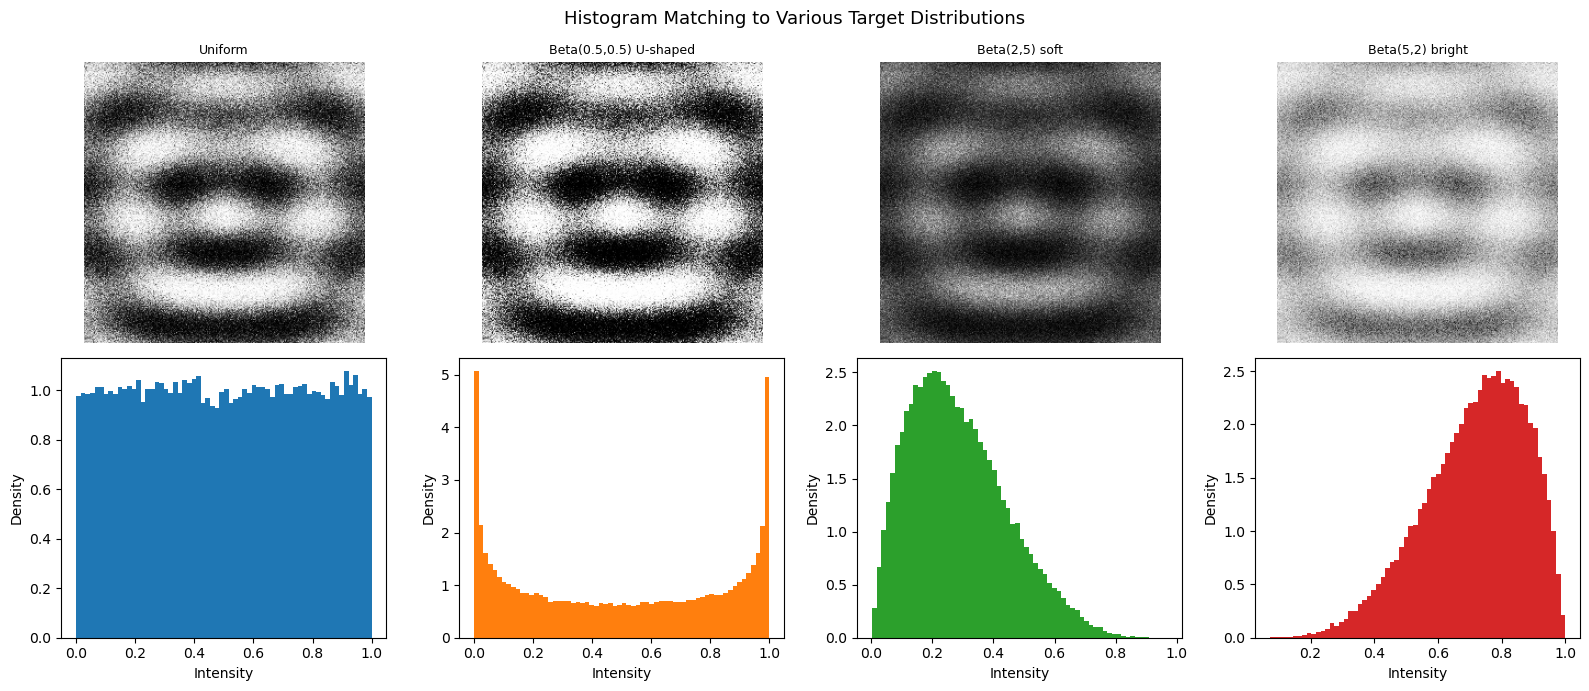

In [4]:
def hist_match(source, target_samples):
    """Match histogram of source to the distribution given by target_samples."""
    src_flat = source.ravel()
    N = len(src_flat)
    # Sort source
    src_idx = np.argsort(src_flat)
    # Sort target to the same length
    tgt_sorted = np.sort(target_samples)[:N] if len(target_samples) >= N else \
                 np.interp(np.linspace(0,1,N), np.linspace(0,1,len(target_samples)),
                           np.sort(target_samples))
    result = np.empty(N)
    result[src_idx] = tgt_sorted
    return np.clip(result.reshape(source.shape), 0, 1)

# Target: beta(2, 5) distribution (moderately bright with soft peak)
rng2 = np.random.default_rng(7)
targets = {
    'Uniform': rng2.uniform(0, 1, f.size),
    'Beta(0.5,0.5) U-shaped': rng2.beta(0.5, 0.5, f.size),
    'Beta(2,5) soft': rng2.beta(2, 5, f.size),
    'Beta(5,2) bright': rng2.beta(5, 2, f.size),
}

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for col, (name, tgt) in enumerate(targets.items()):
    f_match = hist_match(f, tgt)
    axes[0, col].imshow(f_match, cmap='gray', vmin=0, vmax=1)
    axes[0, col].set_title(name, fontsize=9); axes[0, col].axis('off')
    axes[1, col].hist(f_match.ravel(), bins=64, density=True, color=plt.cm.tab10(col))
    axes[1, col].set_xlabel('Intensity'); axes[1, col].set_ylabel('Density')

plt.suptitle('Histogram Matching to Various Target Distributions', fontsize=13)
plt.tight_layout(); plt.savefig('hist_match.png', dpi=100, bbox_inches='tight'); plt.show()

### Interactive gamma correction vs. histogram equalization

A simpler alternative to histogram equalization is **gamma correction**: $\hat{f}(x) = f(x)^{1/\gamma}$. The slider lets you compare the two approaches.

In [ ]:
def compare_gamma_eq(gamma=1.0):
    f_gamma = np.clip(f ** (1.0 / gamma), 0, 1)
    fig, axes = plt.subplots(1, 3, figsize=(13, 4))
    for ax, img, title in zip(axes, [f, f_gamma, f_eq],
                               ['Original', f'Gamma (γ={gamma:.2f})', 'Hist. Eq.']):
        ax.imshow(img, cmap='gray', vmin=0, vmax=1)
        ax.set_title(title); ax.axis('off')
    plt.tight_layout(); plt.show()

interact(compare_gamma_eq, gamma=FloatSlider(min=0.2, max=5.0, step=0.1, value=1.0,
                                              description='γ'));

### Snippet

In [5]:
STATIC_SNAPSHOT = True
if STATIC_SNAPSHOT:
    import matplotlib
    matplotlib.use('Agg')
    import matplotlib.pyplot as _plt
    fig, axes = _plt.subplots(2, 3, figsize=(10, 7))
    imgs = [f, f_eq, hist_match(f, np.random.default_rng(3).beta(5,2,f.size))]
    titles = ['Original', 'Equalized', 'Matched (Beta 5,2)']
    for col in range(3):
        axes[0, col].imshow(imgs[col], cmap='gray', vmin=0, vmax=1)
        axes[0, col].set_title(titles[col]); axes[0, col].axis('off')
        axes[1, col].hist(imgs[col].ravel(), bins=48, density=True,
                          color=plt.cm.tab10(col), alpha=0.8)
        axes[1, col].set_xlabel('Intensity')
    fig.tight_layout()
    fig.savefig('snippet.png', dpi=150, bbox_inches='tight')

## Takeaways

- **Histogram equalization** maps pixel intensities through the empirical CDF, resulting in a (nearly) flat histogram and maximum contrast.
- **Histogram matching** generalizes equalization to any target distribution via $G^{-1} \circ F$ — equivalent to 1D optimal transport.
- The key limitation of global equalization is that it can over-amplify noise in flat regions and lose local contrast. Adaptive methods (CLAHE) address this.

## Bibliography

- R. C. Gonzalez & R. E. Woods, *Digital Image Processing*, Prentice Hall, 2008.
- S. M. Pizer et al., *Adaptive histogram equalization and its variations*, CVGIP 39, 1987.
- G. Peyré & M. Cuturi, *Computational Optimal Transport*, Foundations and Trends in ML, 2019.